<div class="markdown-google-sans">
  <h1>Welcome to Colab!</h1>
</div>

<div class="markdown-google-sans">
  <h2>Explore the Gemini API</h2>
  <p>The Gemini API gives you access to Gemini models created by Google DeepMind. Gemini models are built from the ground up to be multimodal, so you can reason seamlessly across text, images, code, and audio.
  </p>
  <strong>How to get started</strong>
    <ol>
      <li>Go to <a href="https://aistudio.google.com/">Google AI Studio</a> and log in with your Google account.</li>
      <li><a href="https://aistudio.google.com/app/apikey">Create an API key</a>.</li>
      <li>Use a quickstart for <a href="https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/Prompting.ipynb">Python</a>, or call the REST API using <a href="https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/rest/Prompting_REST.ipynb">curl</a>.</li>
      </ol>
  <strong>Explore use cases</strong>
    <ul>
      <li><a href="https://colab.research.google.com/github/google-gemini/cookbook/blob/main/examples/Market_a_Jet_Backpack.ipynb">Create a marketing campaign</a></li>
      <li><a href="https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/Audio.ipynb">Analyze audio recordings</a></li>
      <li><a href="https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/System_instructions.ipynb">Use System instructions in chat</a></li>
    </ul>
  <p>To learn more, check out the <a href="https://github.com/google-gemini/cookbook">Gemini cookbook</a> or visit the <a href="https://ai.google.dev/docs/">Gemini API documentation</a>.
  </p>
</div>


<msg desc="Text shown above a link to https://www.youtube.com/watch?v=V7RXyqFUR98 which highlights some helpful features in Colab">Colab now has AI features powered by <a href="https://gemini.google.com">Gemini</a>. The video below provides information on how to use these features, whether you're new to Python, or a seasoned veteran.</msg>

<center>
  <a href="https://www.youtube.com/watch?v=V7RXyqFUR98" target="_blank">
  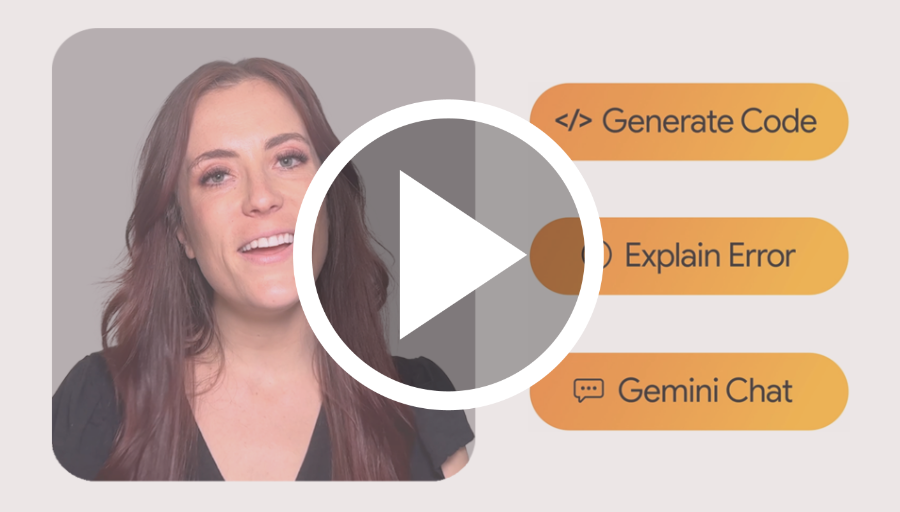
  </a>
</center>

<div class="markdown-google-sans">
  <h2>What is Colab?</h2>
</div>

Colab, or "Colaboratory", allows you to write and execute Python in your browser, with
- Zero configuration required
- Access to GPUs free of charge
- Easy sharing

Whether you're a **student**, a **data scientist** or an **AI researcher**, Colab can make your work easier. Watch [Introduction to Colab](https://www.youtube.com/watch?v=inN8seMm7UI) or [Colab Features You May Have Missed](https://www.youtube.com/watch?v=rNgswRZ2C1Y) to learn more, or just get started below!

<div class="markdown-google-sans">

## **Getting started**
</div>

The document you are reading is not a static web page, but an interactive environment called a **Colab notebook** that lets you write and execute code.

For example, here is a **code cell** with a short Python script that computes a value, stores it in a variable, and prints the result:

In [ ]:
seconds_in_a_day = 24 * 60 * 60
seconds_in_a_day

86400

To execute the code in the above cell, select it with a click and then either press the play button to the left of the code, or use the keyboard shortcut "Command/Ctrl+Enter". To edit the code, just click the cell and start editing.

Variables that you define in one cell can later be used in other cells:

In [ ]:
seconds_in_a_week = 7 * seconds_in_a_day
seconds_in_a_week

604800

Colab notebooks allow you to combine **executable code** and **rich text** in a single document, along with **images**, **HTML**, **LaTeX** and more. When you create your own Colab notebooks, they are stored in your Google Drive account. You can easily share your Colab notebooks with co-workers or friends, allowing them to comment on your notebooks or even edit them. To learn more, see [Overview of Colab](/notebooks/basic_features_overview.ipynb). To create a new Colab notebook you can use the File menu above, or use the following link: [create a new Colab notebook](http://colab.research.google.com#create=true).

Colab notebooks are Jupyter notebooks that are hosted by Colab. To learn more about the Jupyter project, see [jupyter.org](https://www.jupyter.org).

<div class="markdown-google-sans">

## Data science
</div>

With Colab you can harness the full power of popular Python libraries to analyze and visualize data. The code cell below uses **numpy** to generate some random data, and uses **matplotlib** to visualize it. To edit the code, just click the cell and start editing.

You can import your own data into Colab notebooks from your Google Drive account, including from spreadsheets, as well as from Github and many other sources. To learn more about importing data, and how Colab can be used for data science, see the links below under [Working with Data](#working-with-data).

Processing Image 1: /content/sample_data/RGB image 1.jpg (Resized to (2736, 1824))


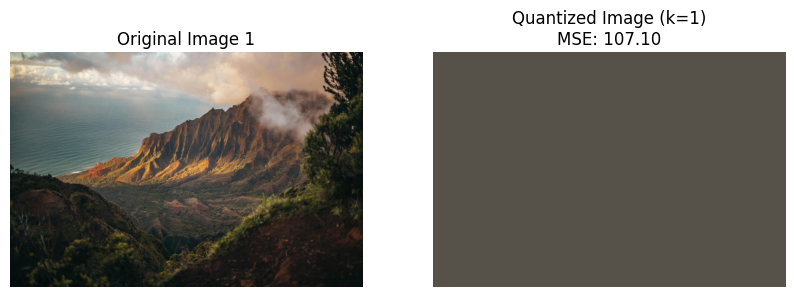

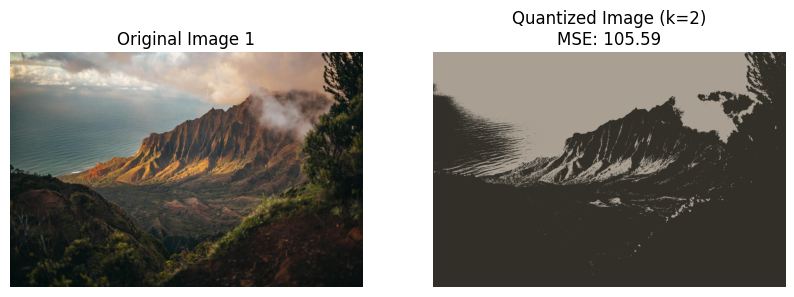

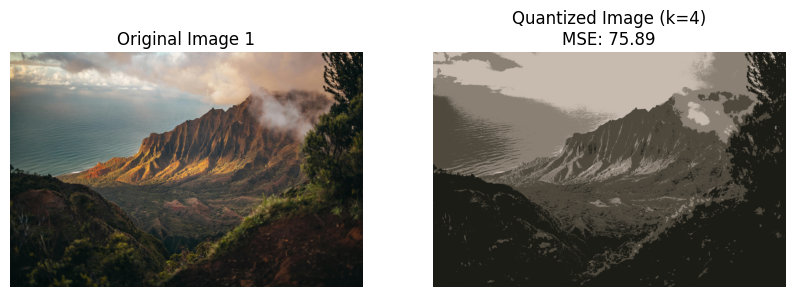

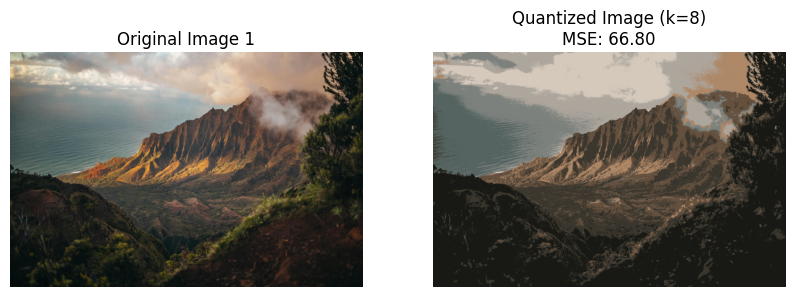

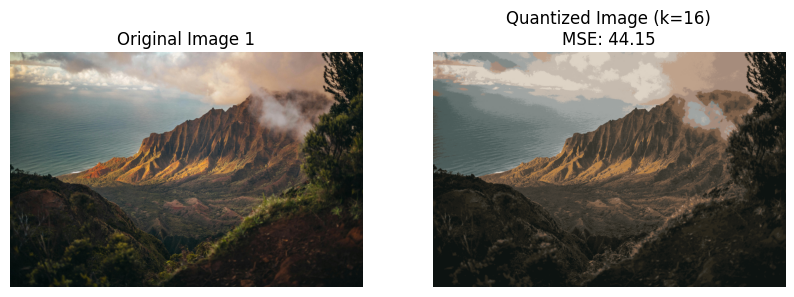

Processing Image 2: /content/sample_data/RGB image 2.jpg (Resized to (3000, 2000))


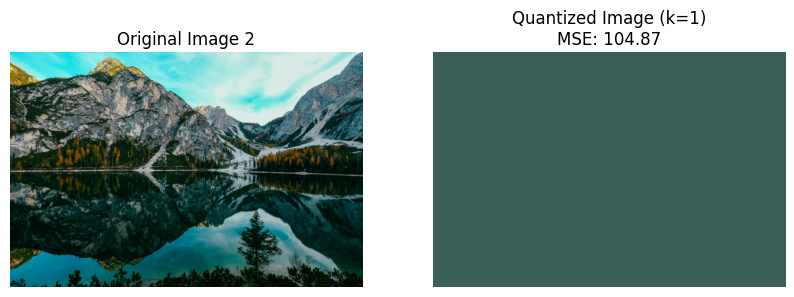

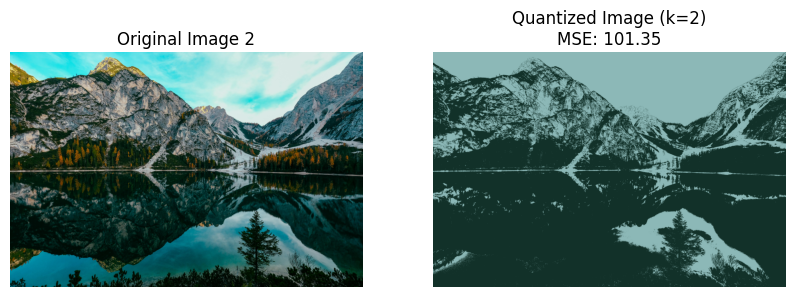

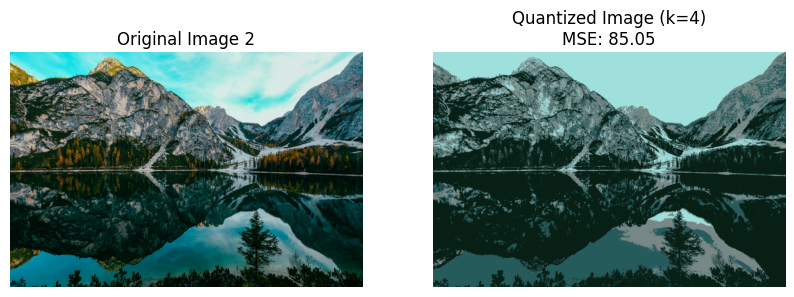

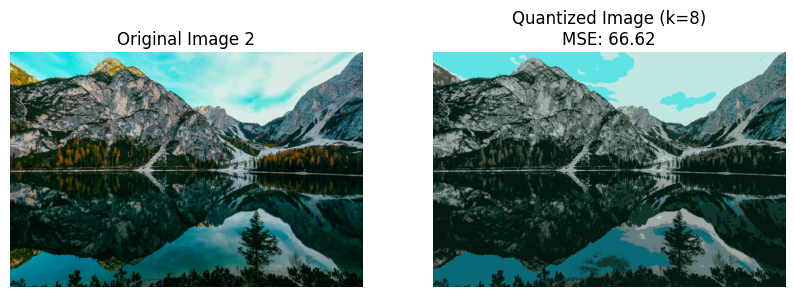

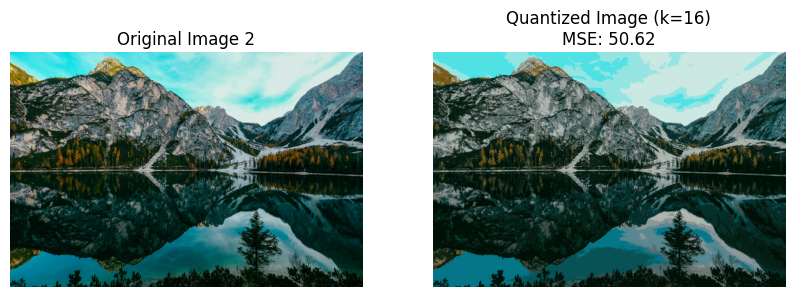

Processing Image 3: /content/sample_data/RGB image 3.jpg (Resized to (2113, 1423))


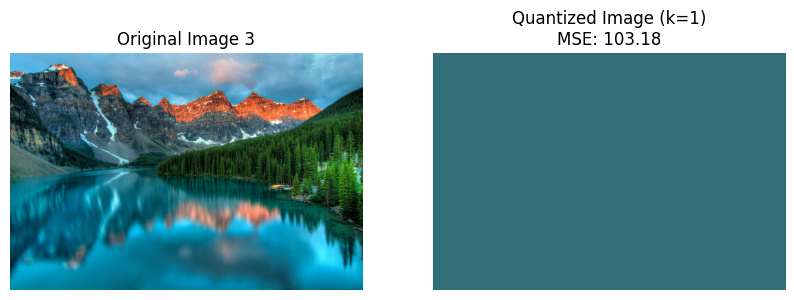

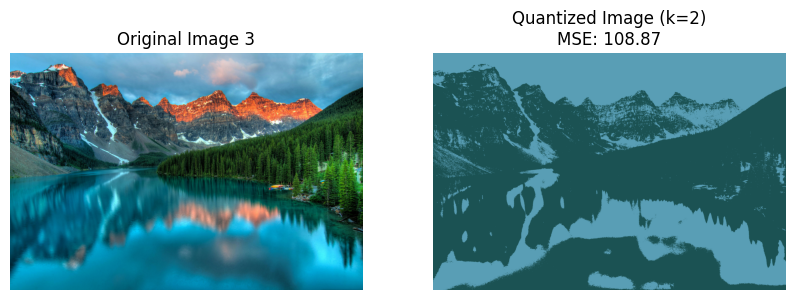

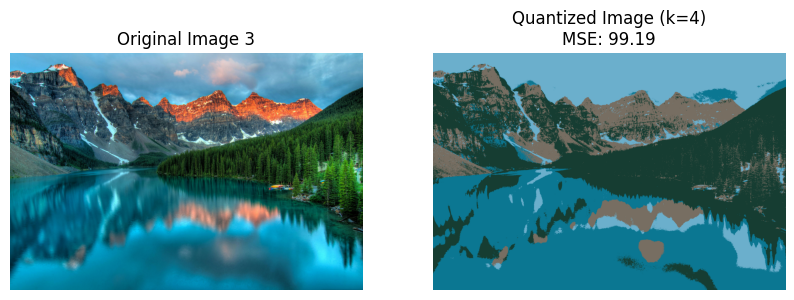

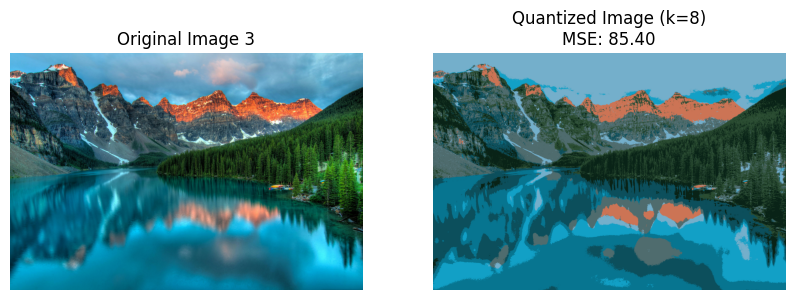

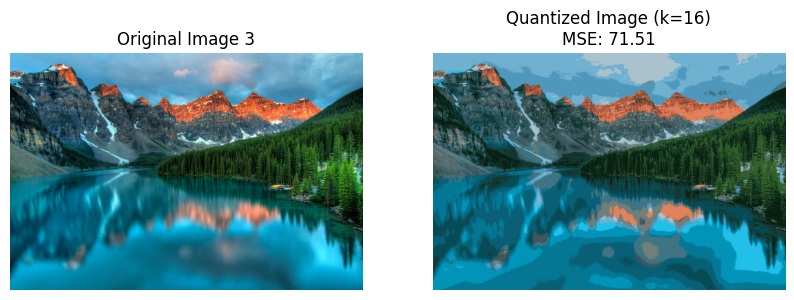

In [ ]:
#Ans 1

import numpy as np
import cv2
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# Function to calculate Mean Squared Error (MSE)
def calculate_mse(original_image, quantized_image):
    return mean_squared_error(original_image.flatten(), quantized_image.flatten())

# Function to perform k-Means image quantization using MiniBatchKMeans
def kmeans_quantization(image, k, max_iter=100):
    # Reshape the image to be a list of pixels
    pixel_values = image.reshape((-1, 3))
    pixel_values = np.float32(pixel_values)

    # Use MiniBatchKMeans for faster performance
    kmeans = MiniBatchKMeans(n_clusters=k, random_state=0, max_iter=max_iter, batch_size=1000, n_init=10)
    kmeans.fit(pixel_values)

    # Get the cluster centers (quantized colors)
    centers = np.uint8(kmeans.cluster_centers_)

    # Map each pixel to its nearest center
    labels = kmeans.labels_

    # Reshape labels back to the image dimensions
    quantized_image = centers[labels.flatten()]
    quantized_image = quantized_image.reshape(image.shape)

    return quantized_image

# Function to plot original and quantized images
def plot_images(original, quantized, k, mse, image_index):
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
    plt.title(f'Original Image {image_index}')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(cv2.cvtColor(quantized, cv2.COLOR_BGR2RGB))
    plt.title(f'Quantized Image (k={k})\nMSE: {mse:.2f}')
    plt.axis('off')

    plt.show()

# Main function to process three images
def process_images(image_paths, resize_factor=0.5):
    # Varying values of k for quantization
    k_values = [1, 2, 4, 8, 16]

    for image_index, image_path in enumerate(image_paths):
        # Load the image
        image = cv2.imread(image_path)

        if image is None:
            print(f"Failed to load image: {image_path}")
            continue

        # Resize the image to speed up processing
        height, width = image.shape[:2]
        new_size = (int(width * resize_factor), int(height * resize_factor))
        resized_image = cv2.resize(image, new_size)

        print(f"Processing Image {image_index + 1}: {image_path} (Resized to {new_size})")

        # Perform quantization for each k
        for k in k_values:
            quantized_image = kmeans_quantization(resized_image, k)

            # Calculate Mean Squared Error
            mse = calculate_mse(resized_image, quantized_image)

            # Display the original and quantized images
            plot_images(resized_image, quantized_image, k, mse, image_index + 1)

if __name__ == "__main__":
    # List of paths to the three images
    image_paths = [
        "/content/sample_data/RGB image 1.jpg",  # first image
        "/content/sample_data/RGB image 2.jpg",  # second image
        "/content/sample_data/RGB image 3.jpg"   # third image
    ]

    process_images(image_paths, resize_factor=0.5)  # Resize images to 50% of their original size for faster processing




Number of connected components (excluding background): 26369


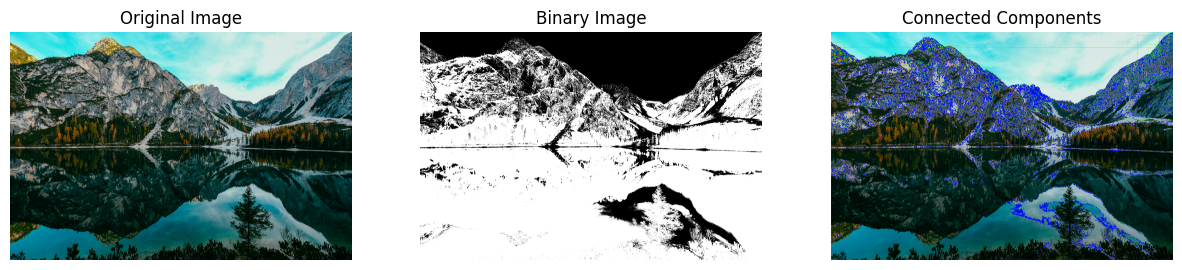

In [ ]:
#Ans 2
import cv2
import numpy as np
import matplotlib.pyplot as plt

def find_connected_components(image):
    """
    Find and visualize connected components in the image.

    :param image: Input RGB image
    """
    # Convert to grayscale
    gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Apply a binary threshold (Otsu's thresholding)
    _, binary_image = cv2.threshold(gray_image, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    # Find connected components
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(binary_image, connectivity=8)

    # Display the number of connected components (excluding the background component)
    print(f"Number of connected components (excluding background): {num_labels - 1}")

    # Create an output image to visualize the components
    output_image = image.copy()

    # Loop over the connected components and draw bounding boxes
    for i in range(1, num_labels):  # Skipping label 0 (background)
        x, y, w, h, area = stats[i]

        # Draw a bounding box around each component
        cv2.rectangle(output_image, (x, y), (x + w, y + h), (0, 255, 0), 2)

        # Optionally, draw the centroid
        cx, cy = centroids[i]
        cv2.circle(output_image, (int(cx), int(cy)), 5, (255, 0, 0), -1)

    # Plot the original image, binary image, and output image
    plt.figure(figsize=(15, 8))
    plt.subplot(1, 3, 1)
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title("Original Image")
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(binary_image, cmap='gray')
    plt.title("Binary Image")
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(cv2.cvtColor(output_image, cv2.COLOR_BGR2RGB))
    plt.title("Connected Components")
    plt.axis('off')

    plt.show()

def main():
    # Load an image /your image path)
    image_url = '/content/sample_data/RGB image 2.jpg'
    image = cv2.imread(image_url)

    if image is None:
        print(f"Error: Couldn't load the image at {image_url}.")
        return

    # Find and visualize connected components
    find_connected_components(image)

if __name__ == "__main__":
    main()


PSNR between downsampled and reference image: 31.06 dB
MSE between downsampled and reference image: 50.96


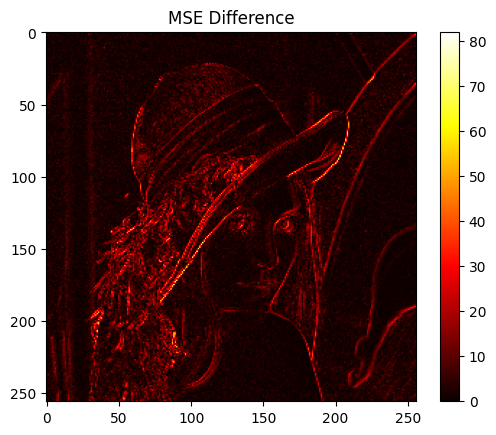

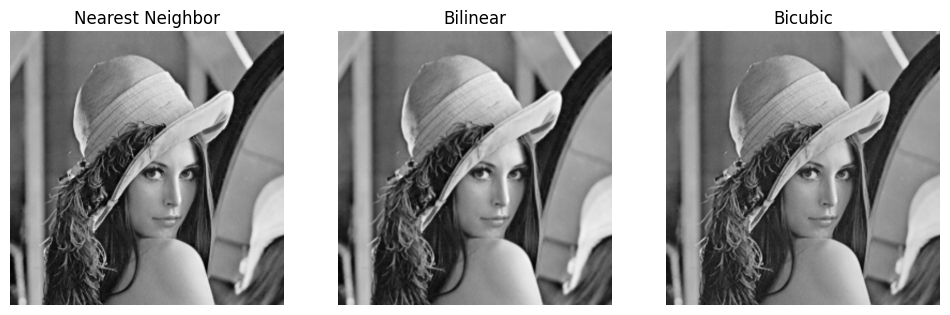

In [ ]:
#Ans 3
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import mean_squared_error as mse

def downsample_image(image, size=(256, 256)):
    """
    Downsample the image to the given size.

    :param image: Input image.
    :param size: The target size for downsampling (default 256x256).
    :return: Downsampled image.
    """
    return cv2.resize(image, size, interpolation=cv2.INTER_AREA)

def compare_images(image1, image2):
    """
    Compare two images by calculating the PSNR and MSE.

    :param image1: First input image.
    :param image2: Second input image.
    :return: PSNR value and MSE value.
    """
    psnr_value = psnr(image1, image2)
    mse_value = mse(image1, image2)
    return psnr_value, mse_value

def resize_image(image, size=(512, 512), method='nearest'):
    """
    Resize the image to the given size using the specified interpolation method.

    :param image: Input image.
    :param size: The target size for resizing (default 512x512).
    :param method: Interpolation method ('nearest', 'bilinear', 'bicubic').
    :return: Resized image.
    """
    if method == 'nearest':
        return cv2.resize(image, size, interpolation=cv2.INTER_NEAREST)
    elif method == 'bilinear':
        return cv2.resize(image, size, interpolation=cv2.INTER_LINEAR)
    elif method == 'bicubic':
        return cv2.resize(image, size, interpolation=cv2.INTER_CUBIC)

def plot_images(images, titles):
    """
    Plot a set of images with titles.

    :param images: List of images to plot.
    :param titles: List of titles for the images.
    """
    plt.figure(figsize=(12, 8))
    for i, (image, title) in enumerate(zip(images, titles)):
        plt.subplot(1, len(images), i + 1)
        plt.imshow(image, cmap='gray')
        plt.title(title)
        plt.axis('off')
    plt.show()

def plot_mse_difference(image1, image2):
    """
    Plot the Mean Squared Error (MSE) difference between two images.

    :param image1: First image.
    :param image2: Second image.
    """
    mse_diff = np.abs(image1.astype('float') - image2.astype('float'))
    plt.imshow(mse_diff, cmap='hot')
    plt.colorbar()
    plt.title('MSE Difference')
    plt.show()

def main():
    # Step 1: Load the original grayscale 'lena_gray_512.tif' image
    image_512 = cv2.imread('/content/sample_data/lena_gray_512.tif', cv2.IMREAD_GRAYSCALE)

    # Step 2: Downsample the image to 256x256
    image_256_downsampled = downsample_image(image_512, size=(256, 256))
    cv2.imwrite('reduce_lena_256.tif', image_256_downsampled)

    # Step 3: Load the reference 'lena_gray_256.tif' image
    image_256_reference = cv2.imread('/content/sample_data/lena_gray_256.tif', cv2.IMREAD_GRAYSCALE)

    # Step 4: Compare the downsampled image with the reference image (PSNR and MSE)
    psnr_value, mse_value = compare_images(image_256_downsampled, image_256_reference)
    print(f"PSNR between downsampled and reference image: {psnr_value:.2f} dB")
    print(f"MSE between downsampled and reference image: {mse_value:.2f}")

    # Plot the MSE difference
    plot_mse_difference(image_256_downsampled, image_256_reference)

    # Step 5: Resize the downsampled image back to 512x512 using different interpolation methods
    resized_nearest = resize_image(image_256_downsampled, size=(512, 512), method='nearest')
    resized_bilinear = resize_image(image_256_downsampled, size=(512, 512), method='bilinear')
    resized_bicubic = resize_image(image_256_downsampled, size=(512, 512), method='bicubic')

    # Step 6: Plot the resized images
    plot_images([resized_nearest, resized_bilinear, resized_bicubic],
                ['Nearest Neighbor', 'Bilinear', 'Bicubic'])

if __name__ == "__main__":
    main()


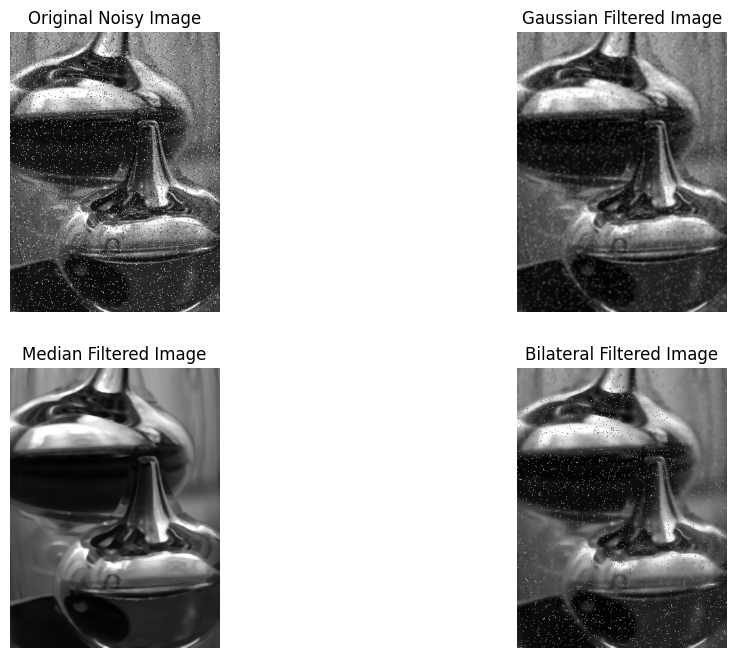

In [1]:
#Ans4
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load the noisy image from the database (path to the noisy image file)
noisy_image = cv2.imread('/content/sample_data/Noisy image.png', cv2.IMREAD_GRAYSCALE)

# Step 1: Apply Gaussian Filter to reduce Gaussian noise
gaussian_filtered = cv2.GaussianBlur(noisy_image, (5, 5), 0)

# Step 2: Apply Median Filter to reduce salt-and-pepper noise
median_filtered = cv2.medianBlur(noisy_image, 5)

# Step 3: Apply Bilateral Filter for edge-preserving smoothing
bilateral_filtered = cv2.bilateralFilter(noisy_image, 9, 75, 75)

# Plot the original and filtered images
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.imshow(noisy_image, cmap='gray')
plt.title('Original Noisy Image')
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(gaussian_filtered, cmap='gray')
plt.title('Gaussian Filtered Image')
plt.axis('off')

plt.subplot(2, 2, 3)
plt.imshow(median_filtered, cmap='gray')
plt.title('Median Filtered Image')
plt.axis('off')

plt.subplot(2, 2, 4)
plt.imshow(bilateral_filtered, cmap='gray')
plt.title('Bilateral Filtered Image')
plt.axis('off')

plt.show()


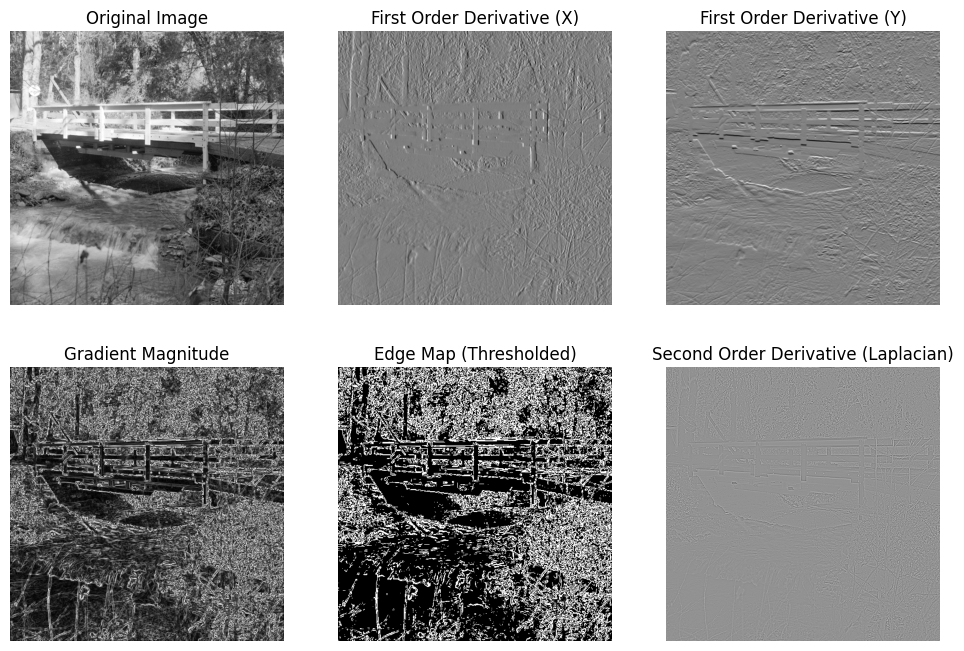

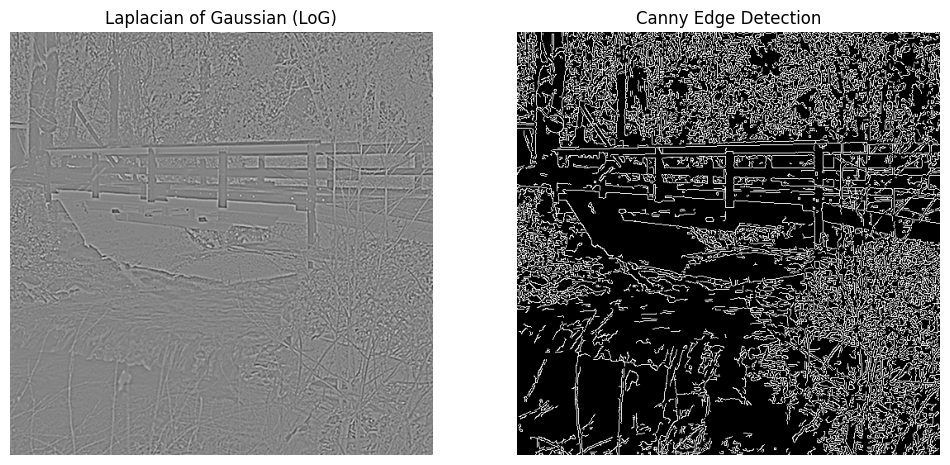

In [2]:
#Ans5
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load the image (change to the appropriate path of your image)
image = cv2.imread('/content/sample_data/walkbridge.tif', cv2.IMREAD_GRAYSCALE)

# Step 1: First order derivatives using Sobel filter
# Derivative along x
sobel_x = cv2.Sobel(image, cv2.CV_64F, 1, 0, ksize=3)
# Derivative along y
sobel_y = cv2.Sobel(image, cv2.CV_64F, 0, 1, ksize=3)

# Step 2: Gradient magnitude
gradient_magnitude = np.sqrt(sobel_x**2 + sobel_y**2)
gradient_magnitude = np.uint8(gradient_magnitude)

# Step 3: Thresholding to create an edge map
_, edge_map = cv2.threshold(gradient_magnitude, 100, 255, cv2.THRESH_BINARY)

# Step 4: Second order derivative (Laplacian)
laplacian = cv2.Laplacian(image, cv2.CV_64F)

# Step 5: Laplacian of Gaussian (LoG)
blurred_image = cv2.GaussianBlur(image, (3, 3), 0)
log = cv2.Laplacian(blurred_image, cv2.CV_64F)

# Step 6: Canny edge detection
canny_edges = cv2.Canny(image, 100, 200)

# Plotting the results
plt.figure(figsize=(12, 8))

plt.subplot(2, 3, 1)
plt.imshow(image, cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(2, 3, 2)
plt.imshow(sobel_x, cmap='gray')
plt.title('First Order Derivative (X)')
plt.axis('off')

plt.subplot(2, 3, 3)
plt.imshow(sobel_y, cmap='gray')
plt.title('First Order Derivative (Y)')
plt.axis('off')

plt.subplot(2, 3, 4)
plt.imshow(gradient_magnitude, cmap='gray')
plt.title('Gradient Magnitude')
plt.axis('off')

plt.subplot(2, 3, 5)
plt.imshow(edge_map, cmap='gray')
plt.title('Edge Map (Thresholded)')
plt.axis('off')

plt.subplot(2, 3, 6)
plt.imshow(laplacian, cmap='gray')
plt.title('Second Order Derivative (Laplacian)')
plt.axis('off')

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(log, cmap='gray')
plt.title('Laplacian of Gaussian (LoG)')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(canny_edges, cmap='gray')
plt.title('Canny Edge Detection')
plt.axis('off')

plt.show()
